In [10]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
import os
import glob

# Define your dataset class
class QueenDataset(Dataset):
    def __init__(self, root_dir, transform_image=None, transform_mask=None):
        self.root_dir = root_dir
        self.transform_image = transform_image
        self.transform_mask = transform_mask
        self.image_paths = []
        self.mask_paths = []

        # Loop through each category folder
        for category in os.listdir(root_dir):
            category_path = os.path.join(root_dir, category)
            if os.path.isdir(category_path):
                images_dir = os.path.join(category_path, 'Images')
                masks_dir = os.path.join(category_path, 'Masks')
                
                # Get all image and mask file paths
                self.image_paths.extend(glob.glob(os.path.join(images_dir, '*.png')))  # Adjust the file extension as needed
                self.mask_paths.extend(glob.glob(os.path.join(masks_dir, '*.png')))   # Adjust the file extension as needed
        
        # Check if image and mask paths were found
        if len(self.image_paths) == 0:
            raise ValueError("No images found in the specified directory.")
        if len(self.mask_paths) == 0:
            raise ValueError("No masks found in the specified directory.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        # Load images and masks
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Apply transformations
        if self.transform_image:
            image = self.transform_image(image)
        if self.transform_mask:
            mask = self.transform_mask(mask)

        return image, mask


# Create transformations for image and mask
transform_image = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

transform_mask = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Create the dataset and DataLoader
train_dataset = QueenDataset(root_dir='/kaggle/input/queendataset/Queensland Dataset CE42', 
                              transform_image=transform_image, 
                              transform_mask=transform_mask)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [11]:
import torch
import torch.nn as nn

class SimpleUNet(nn.Module):
    def __init__(self):
        super(SimpleUNet, self).__init__()
        self.encoder1 = self.conv_block(3, 16)
        self.encoder2 = self.conv_block(16, 32)
        self.encoder3 = self.conv_block(32, 64)
        self.bottleneck = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.decoder3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.decoder1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(16, 1, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(enc1)
        enc3 = self.encoder3(enc2)

        bottleneck = self.bottleneck(enc3)

        dec3 = self.decoder3(bottleneck)
        dec3 = self.match_dimensions(dec3, enc3)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.conv_block(128, 64)(dec3)

        dec2 = self.decoder2(dec3)
        dec2 = self.match_dimensions(dec2, enc2)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.conv_block(64, 32)(dec2)

        dec1 = self.decoder1(dec2)
        dec1 = self.match_dimensions(dec1, enc1)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.conv_block(32, 16)(dec1)

        return self.final_conv(dec1)
    
    def match_dimensions(self, dec_tensor, enc_tensor):
        # Match dimensions by cropping or padding
        if dec_tensor.size()[2:] != enc_tensor.size()[2:]:
            return nn.functional.interpolate(dec_tensor, size=enc_tensor.size()[2:], mode='bilinear', align_corners=True)
        return dec_tensor


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = SimpleUNet().to(device)

criterion = torch.nn.BCEWithLogitsLoss()  # Since it's a binary segmentation task
optimizer = optim.Adam(unet.parameters(), lr=0.001)

In [3]:
def calculate_iou(preds, masks, threshold=0.5):
    """Calculate IoU between predicted masks and ground truth."""
    preds = torch.sigmoid(preds)  # Apply sigmoid for binary classification
    preds = (preds > threshold).float()  # Binarize the predictions with the threshold

    intersection = torch.sum(preds * masks)  # Calculate intersection
    union = torch.sum(preds) + torch.sum(masks) - intersection  # Calculate union

    iou = intersection / union
    return iou

num_epochs = 10

for epoch in range(num_epochs):
    unet.train()
    epoch_loss = 0
    epoch_iou = 0  

    for images, masks in train_loader:
        images = images
        masks = masks
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = unet(images)
        
        # Compute loss
        loss = criterion(outputs, masks)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        # Compute IoU (accuracy metric)
        iou = calculate_iou(outputs, masks)
        epoch_iou += iou.item()
        
        epoch_loss += loss.item()
        print(epoch_loss)

    avg_loss = epoch_loss / len(train_loader)
    avg_iou = epoch_iou / len(train_loader)  # Average IoU over the epoch

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss}, IoU: {avg_iou}")

# Save the trained model
torch.save(unet.state_dict(), "unet_queen_dataset.pth")


0.7604458928108215
1.480265498161316
2.1535125970840454
2.771464765071869
3.5712740421295166
4.163057804107666
4.697636663913727
5.3004685044288635
5.84704864025116
6.375524699687958
7.277819037437439
7.795251905918121
8.397122144699097
8.934533774852753
9.415280908346176
10.05773177742958
10.568924278020859
11.226231843233109
11.6597398519516
12.172455430030823
13.346505880355835
13.843632310628891
14.381440430879593
14.892588108778
15.556987434625626
16.103216737508774
16.59348440170288
17.140420854091644
17.768860816955566
18.265739291906357
18.803264528512955
19.26824015378952
19.76248997449875
20.22346332669258
20.849891155958176
21.319945812225342
21.824019610881805
22.26378920674324
22.74898600578308
23.128159373998642
23.71613720059395
24.106641441583633
24.80303058028221
25.194316804409027
25.831607818603516
26.358443439006805
27.65126782655716
28.43644678592682
28.96822589635849
29.451868921518326
29.94707417488098
30.45517897605896
30.987063348293304
31.540070295333862
32.02

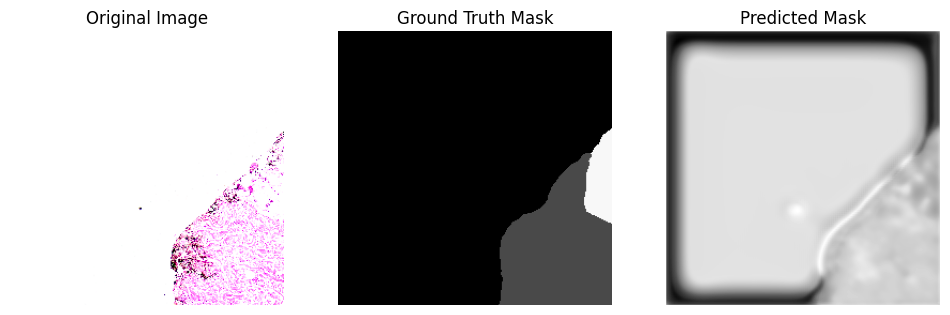

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def show_predictions(images, masks, predictions, idx=0):
    image = images[idx].permute(1, 2, 0).cpu().numpy()  # Convert to (H, W, C) format
    mask = masks[idx].cpu().numpy()
    prediction = predictions[idx].cpu().numpy()

    # If mask and prediction have an extra dimension, remove it
    mask = np.squeeze(mask)
    prediction = np.squeeze(prediction)

    fig, ax = plt.subplots(1, 3, figsize=(12, 6))
    ax[0].imshow(image)
    ax[0].set_title("Original Image")
    ax[0].axis('off')

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("Ground Truth Mask")
    ax[1].axis('off')

    ax[2].imshow(prediction, cmap='gray')
    ax[2].set_title("Predicted Mask")
    ax[2].axis('off')

    plt.show()


# Example of how to integrate this into the training loop or inference step
unet.eval()  # Set model to evaluation mode

# Use one batch from the DataLoader (for visualization after training)
for images, masks in train_loader:
    with torch.no_grad():
        outputs = unet(images)  # Generate predicted masks
        show_predictions(images, masks, outputs, idx=2)  # Show the 0th image in the batch
    break  # We only need one batch for visualization
